In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data3 = pd.read_csv("games.csv")
data3['Release date'] = data3['Release date'].str[-4:]
print(len(data3))
print(len(data3['Name'].unique()))
df_metacritic = data3[data3['Metacritic score'] > 0].copy()
df_metacritic['total_reviews'] = df_metacritic['Positive'] + df_metacritic['Negative']

122611
121455


Successfully parsed dates: 4256/4256
Date parsing success rate: 100.00%


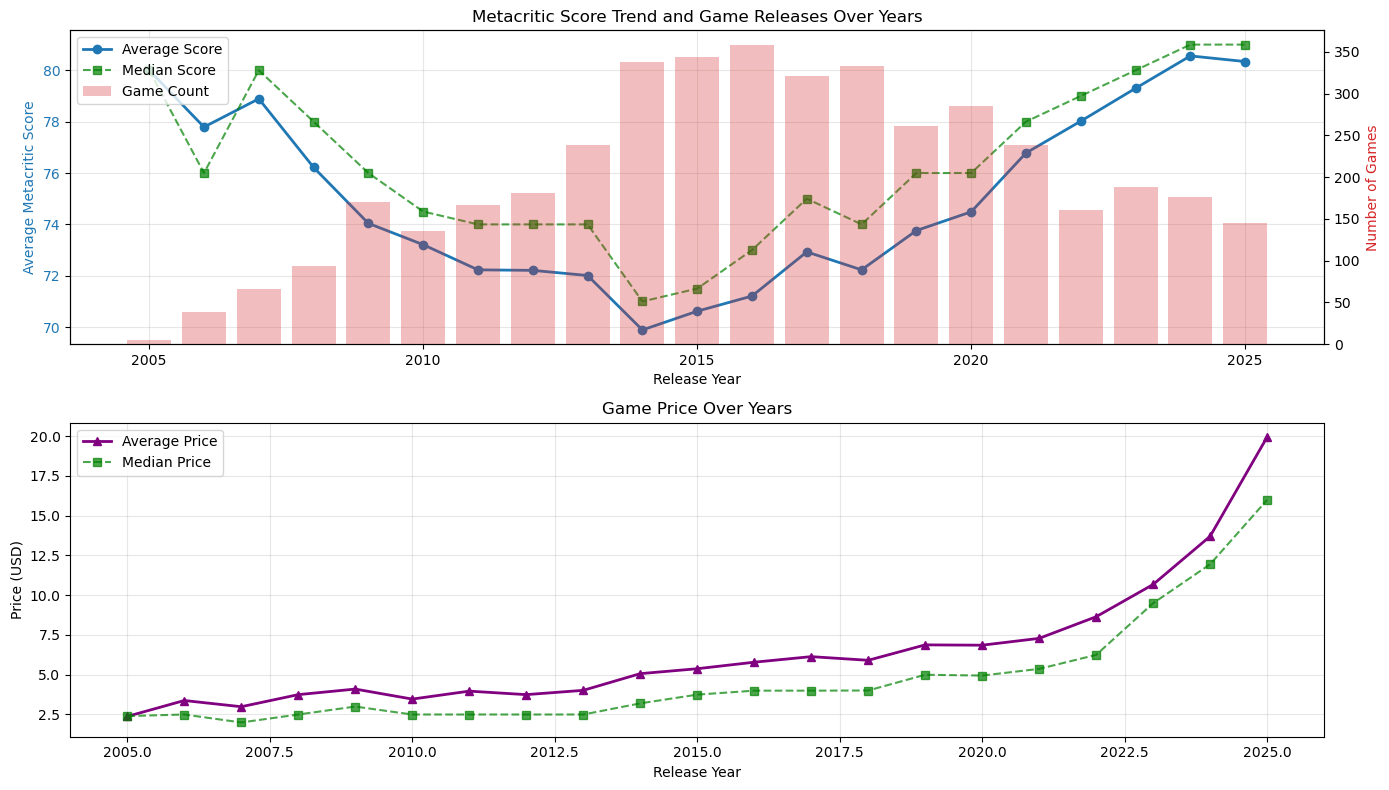

In [3]:
# More robust date parsing function
def parse_release_date(date_str):
    """
    Parse release dates in multiple formats
    """
    if pd.isna(date_str):
        return pd.NaT
    
    date_str = str(date_str).strip()
    
    formats = [
        '%b %d, %Y',
        '%B %d, %Y',
        '%b %Y',
        '%B %Y',
        '%Y-%m-%d',
        '%m/%d/%Y',
        '%d/%m/%Y',
        '%Y',
    ]
    
    for fmt in formats:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except:
            continue
    
    return pd.NaT


# Apply date parsing
df_metacritic['release_date_parsed'] = df_metacritic['Release date'].apply(parse_release_date)


# Check parsing results
date_parsed_count = df_metacritic['release_date_parsed'].notna().sum()
print(f"Successfully parsed dates: {date_parsed_count}/{len(df_metacritic)}")
print(f"Date parsing success rate: {date_parsed_count/len(df_metacritic)*100:.2f}%")


# Extract time features
df_metacritic['release_year'] = df_metacritic['release_date_parsed'].dt.year
df_metacritic['release_month'] = df_metacritic['release_date_parsed'].dt.month
df_metacritic['release_quarter'] = df_metacritic['release_date_parsed'].dt.quarter

# =========================================================
# Yearly aggregation
# =========================================================
yearly_stats = df_metacritic[df_metacritic['release_year'].notna()].groupby('release_year').agg({
    'Metacritic score': ['mean', 'median', 'count'],
    'Price': ['mean', 'median'],
    'Name': 'count',
}).round(2)


yearly_stats.columns = [
    'avg_score', 'median_score', 'scored_games',
    'avg_price', 'median_price',
    'total_games',
]


yearly_stats = yearly_stats[yearly_stats['total_games'] >= 5]
yearly_stats = yearly_stats.sort_index()  # important for plots
# =========================================================
# Plotting
# =========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))


# -------------------------
# AX1: Scores
# -------------------------
ax1.set_xlabel('Release Year')
ax1.set_ylabel('Average Metacritic Score', color='tab:blue')

ax1.plot(yearly_stats.index, yearly_stats['avg_score'],
         color='tab:blue', marker='o', linewidth=2, label='Average Score')

ax1.plot(yearly_stats.index, yearly_stats['median_score'],
         color='green', marker='s', linestyle='--', alpha=0.7, label='Median Score')

ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

ax2_bar = ax1.twinx()
ax2_bar.bar(yearly_stats.index, yearly_stats['total_games'],
            alpha=0.3, color='tab:red', label='Game Count')

ax2_bar.set_ylabel('Number of Games', color='tab:red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2_bar.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Metacritic Score Trend and Game Releases Over Years')


# -------------------------
# AX2: Price
# -------------------------
ax2.plot(yearly_stats.index, yearly_stats['avg_price'],
         color='purple', marker='^', linewidth=2, label='Average Price')

ax2.plot(yearly_stats.index, yearly_stats['median_price'],
         color='green', marker='s', linestyle='--', alpha=0.7, label='Median Price')

ax2.set_xlabel('Release Year')
ax2.set_ylabel('Price (USD)')
ax2.set_title('Game Price Over Years')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

From the first graph, we can make the hypothesis that there was an explosion of the number of games in the 2014 years but those were of
bad quality or some standed out making the critics give very low scores on most games. However we can see that the tendency is
reversing nowadays, with less released games and better metacritics scores.

The average price of games is increasing each years, further experimentation should be done to see if it's natural (due to the inflation)
or has another cause.

Lastly, the number of owners of steam's games is very turbulent but they seem to be lesser in the last years.

Successfully parsed dates: 122611/122611
Date parsing success rate: 100.00%


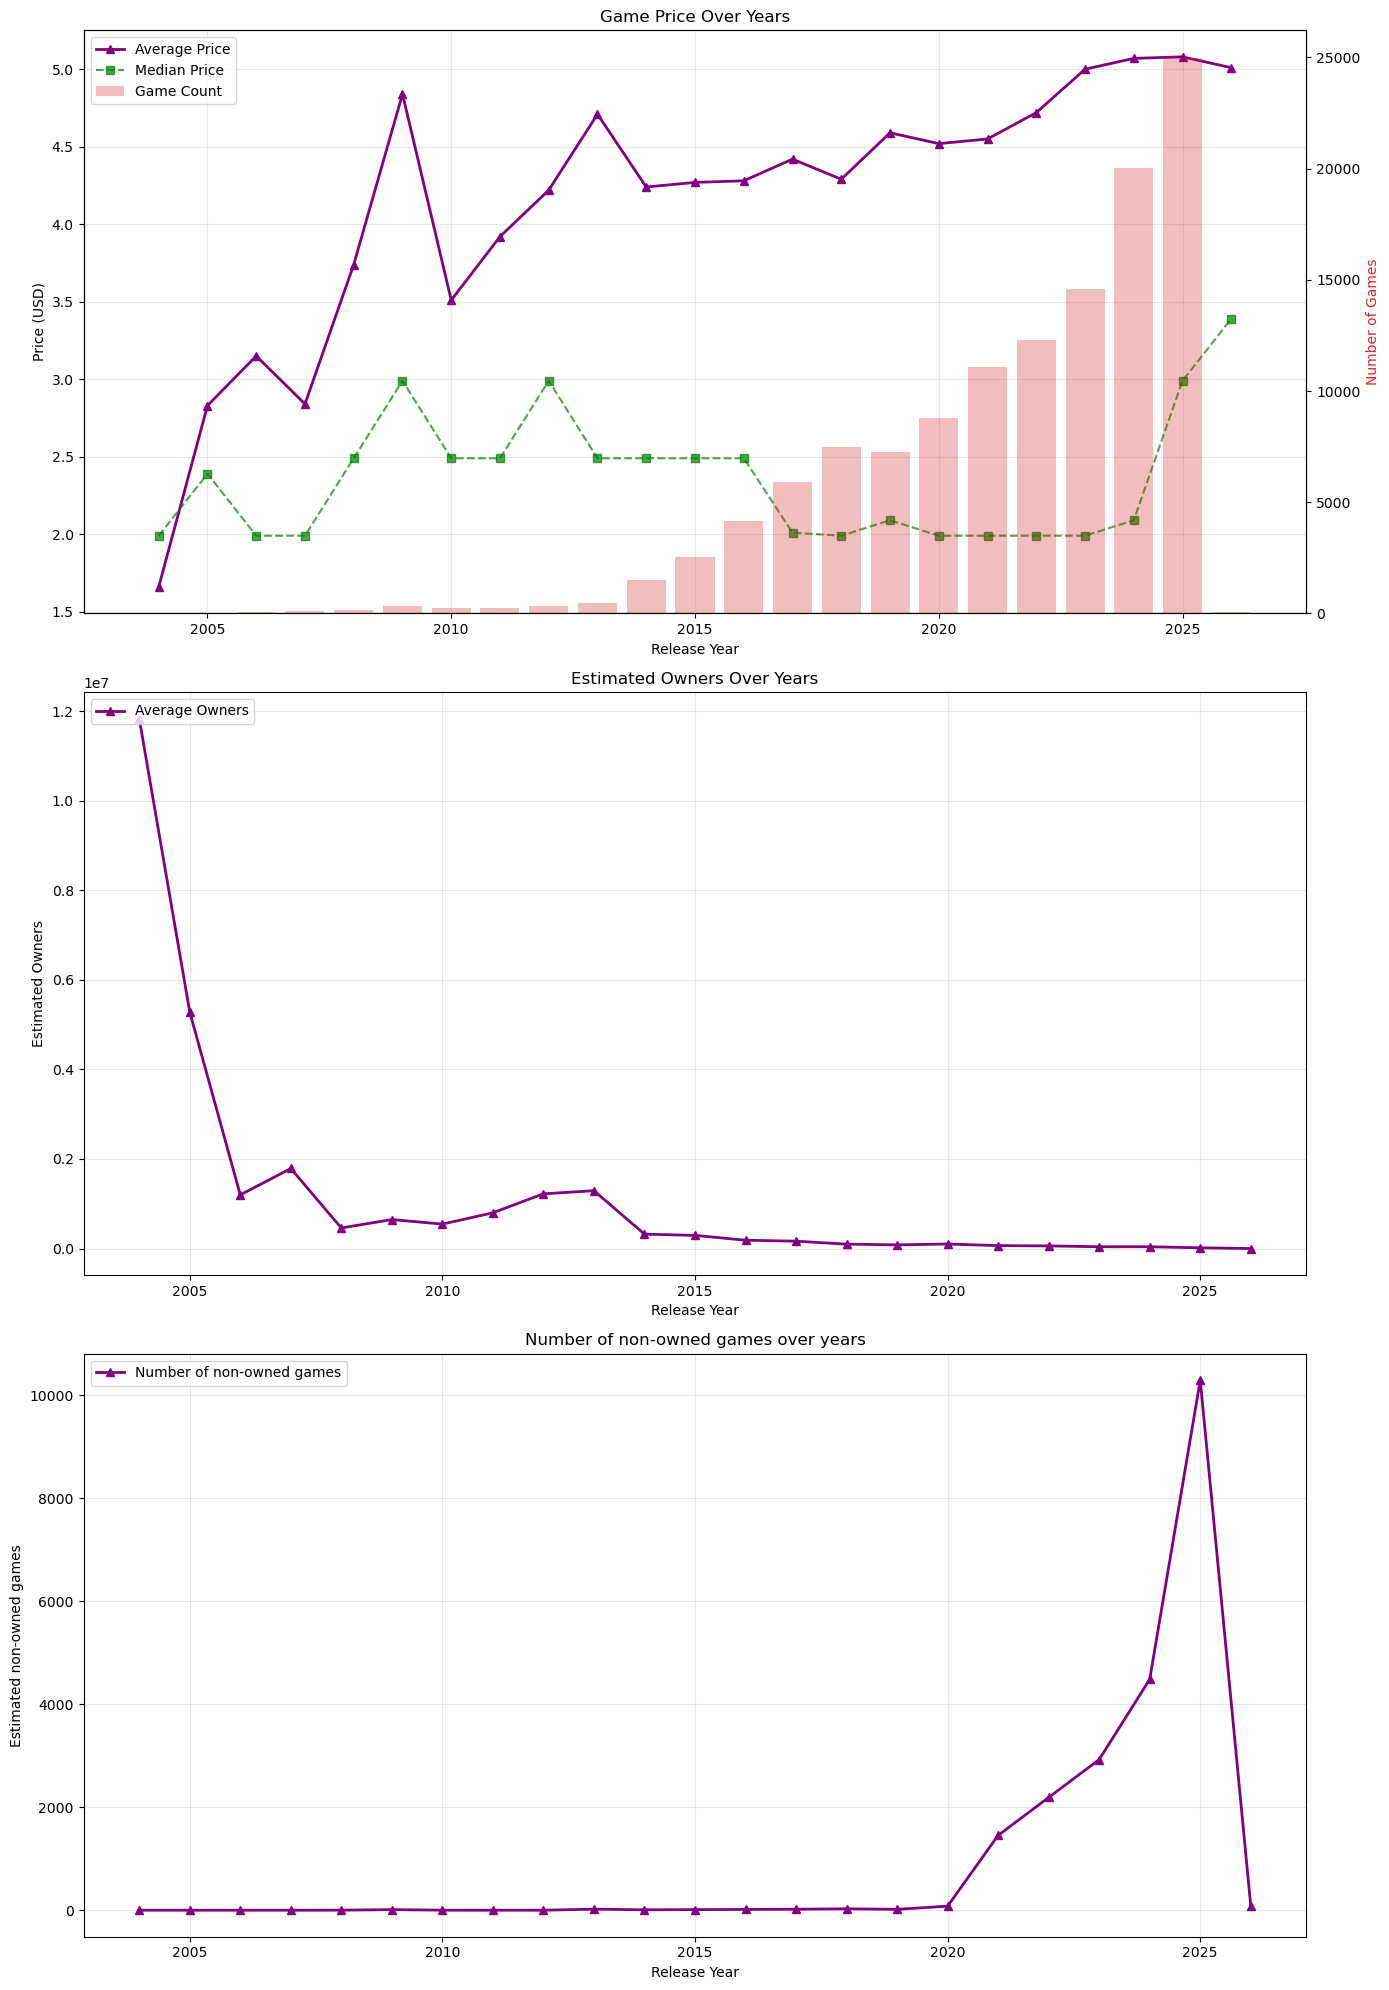

In [4]:
# Apply date parsing
data3['release_date_parsed'] = data3['Release date'].apply(parse_release_date)


# Check parsing results
date_parsed_count = data3['release_date_parsed'].notna().sum()
print(f"Successfully parsed dates: {date_parsed_count}/{len(data3)}")
print(f"Date parsing success rate: {date_parsed_count/len(data3)*100:.2f}%")


# Extract time features
data3['release_year'] = data3['release_date_parsed'].dt.year
data3['release_month'] = data3['release_date_parsed'].dt.month
data3['release_quarter'] = data3['release_date_parsed'].dt.quarter

def parse_owners_range(x):
    if pd.isna(x):
        return None
    
    if isinstance(x, str):
        x = x.replace(',', '').strip()
        
        if '-' in x:
            low, high = x.split('-')
            return (float(low) + float(high)) / 2
        
        return float(x)
    
    return None

data3['owners_num'] = data3['Estimated owners'].apply(parse_owners_range)
data3['zero_owners'] = data3['Estimated owners'] == '0 - 0'

# =========================================================
# Yearly aggregation
# =========================================================
yearly_stats = data3[data3['release_year'].notna()].groupby('release_year').agg({
    'Price': ['mean', 'median'],
    'Name': 'count',
    'owners_num': ['mean', 'median'],
    'zero_owners': 'sum'
}).round(2)


yearly_stats.columns = [
    'avg_price', 'median_price',
    'total_games',
    'avg_nbowner', 'median_nbowner',
    'total_zero_owners'
]


yearly_stats = yearly_stats[yearly_stats['total_games'] >= 5]
yearly_stats = yearly_stats.sort_index()  # important for plots


# =========================================================
# Plotting
# =========================================================
fig, (ax2, ax3, ax4) = plt.subplots(3, 1, figsize=(14, 20))

# -------------------------
# AX2: Price
# -------------------------
ax2.plot(yearly_stats.index, yearly_stats['avg_price'],
         color='purple', marker='^', linewidth=2, label='Average Price')

ax2.plot(yearly_stats.index, yearly_stats['median_price'],
         color='green', marker='s', linestyle='--', alpha=0.7, label='Median Price')

ax2.set_xlabel('Release Year')
ax2.set_ylabel('Price (USD)')
ax2.set_title('Game Price Over Years')
ax2.grid(True, alpha=0.3)
ax2_bar = ax2.twinx()
ax2_bar.bar(yearly_stats.index, yearly_stats['total_games'],
            alpha=0.3, color='tab:red', label='Game Count')

ax2_bar.set_ylabel('Number of Games', color='tab:red')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_bar.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


# -------------------------
# AX3: Owners
# -------------------------
ax3.plot(yearly_stats.index, yearly_stats['avg_nbowner'],
         color='purple', marker='^', linewidth=2, label='Average Owners')

ax3.set_xlabel('Release Year')
ax3.set_ylabel('Estimated Owners')
ax3.set_title('Estimated Owners Over Years')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left')

ax4.plot(yearly_stats.index, yearly_stats['total_zero_owners'],
         color='purple', marker='^', linewidth=2, label='Number of non-owned games')

ax4.set_xlabel('Release Year')
ax4.set_ylabel('Estimated non-owned games')
ax4.set_title('Number of non-owned games over years')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper left')


plt.tight_layout()
plt.show()

Le fait que le prix soit beaucoup plus petit que précédemment ne me choque pas plus que cela car il y a beaucoup de jeux gratuits.

Le deuxième graphique n'est pas très intéressant dans la mesure où on voit l'évolution du nombre de propriétaires non pas en fonction mais selon leur année de parution à la date actuelle. Ainsi, si d'un coup un jeu sorti en 2010 revenait à la mode, son nombre de propriétaire exploserait non pas en 2026 mais en 2010. En revanche on peut voir que les gens ont apparemment plus tendance à aimer les jeux rétros.

D'après le graphique 3, chaque année il y aurait de plus en plus de jeux qui n'auraient pas de propriétaires.

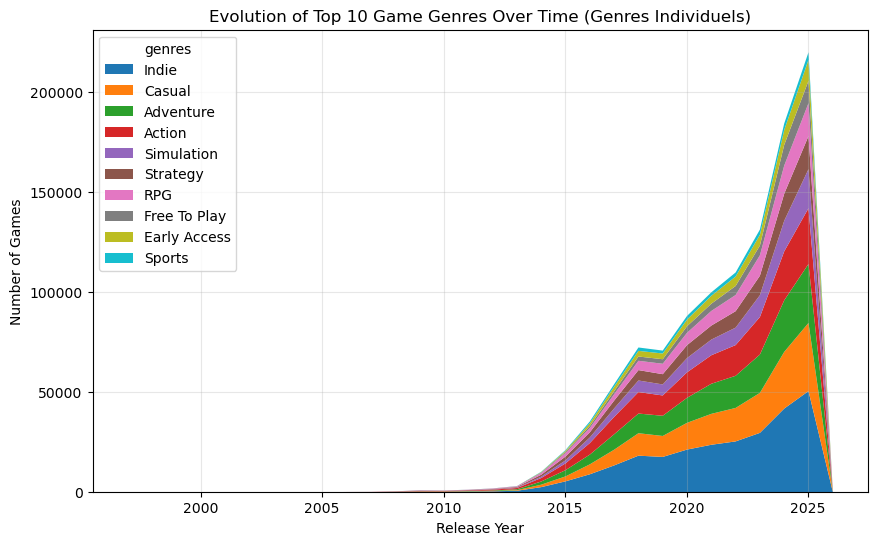

In [6]:
import matplotlib.pyplot as plt

# Exploser les genres
data3['genres'] = data3['Genres'].str.split(',')
data3 = data3.explode('genres')

# Regrouper par année et genre, puis compter le nombre de jeux
genre_year_count = data3.groupby(['release_year', 'genres']).size().unstack(fill_value=0)

# Filtrer les top genres en fonction de leur fréquence globale
genre_counts = data3['genres'].value_counts()
top_genres = genre_counts.head(10).index  # Top 10 genres les plus fréquents

# Garder uniquement les top genres dans genre_year_count
genre_year_count = genre_year_count[top_genres]

# Créer un graphique
fig, ax = plt.subplots(figsize=(10, 6))

# Tracer le graphique
genre_year_count.plot(kind='area', stacked=True, ax=ax, cmap='tab10', linewidth=0)

# Ajouter un titre et des labels
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Games')
ax.set_title(f'Evolution of Top {len(top_genres)} Game Genres Over Time (Genres Individuels)')
ax.grid(True, alpha=0.3)

# Afficher le graphique
plt.show()

Beaucoup de Jeux indie même si la tendance est plus à la hausse pour quelques autres genres. Par contre, truc bizarre comme tout à l'heure, trop de jeux...